In [3]:
# model.py
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.nn as geom_nn
from torch_geometric.nn import HeteroConv, SAGEConv, Linear
from torch_geometric.nn import GCNConv

class DrugEncoder(nn.Module):
    """
    Heterogeneous encoder that computes embeddings for 'drug' nodes
    using relations: drug--binds-->protein and protein--interacts-->protein and drug--interacts-->drug.
    """
    def __init__(self, in_drug, in_protein, hidden_dim=256, out_dim=128):
        super().__init__()
        # two-layer HeteroConv
        conv1 = {
            ("drug", "interacts", "drug"): SAGEConv(in_drug, hidden_dim),
            ("drug", "binds", "protein"): SAGEConv(in_drug, hidden_dim),
            ("protein", "interacts", "protein"): SAGEConv(in_protein, hidden_dim),
            ("protein", "rev_binds", "drug"): SAGEConv(in_protein, hidden_dim)  # reverse relation
        }
        conv2 = {
            ("drug", "interacts", "drug"): SAGEConv(hidden_dim, out_dim),
            ("drug", "binds", "protein"): SAGEConv(hidden_dim, out_dim),
            ("protein", "interacts", "protein"): SAGEConv(hidden_dim, out_dim),
            ("protein", "rev_binds", "drug"): SAGEConv(hidden_dim, out_dim)
        }
        self.conv1 = HeteroConv(conv1, aggr="sum")
        self.conv2 = HeteroConv(conv2, aggr="sum")
        self.lin_drug = Linear(in_drug, hidden_dim)
        self.lin_prot = Linear(in_protein, hidden_dim)

    def forward(self, x_dict, edge_index_dict):
        # prepare reverse binds relation if exists
        if ("drug", "binds", "protein") in edge_index_dict:
            src, dst = edge_index_dict[("drug", "binds", "protein")]
            edge_rev = torch.stack([dst, src], dim=0)
            edge_index_dict[("protein", "rev_binds", "drug")] = edge_rev

        x_drug = self.lin_drug(x_dict["drug"])
        x_prot = self.lin_prot(x_dict["protein"])
        x1 = {"drug": x_drug, "protein": x_prot}
        x1 = self.conv1(x1, edge_index_dict)
        x1 = {k: F.relu(v) for k, v in x1.items()}
        x2 = self.conv2(x1, edge_index_dict)
        # Return the drug embeddings
        return x2["drug"]

class ComboPredictor(nn.Module):
    """
    Combines drug embeddings (by mean pooling) and predicts multi-label side-effects.
    """
    def __init__(self, drug_emb_dim, hidden_dim, num_sideeffects, dropout=0.2):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(drug_emb_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_sideeffects)
        )

    def forward(self, combo_drug_embeddings):
        # combo_drug_embeddings: (batch, k, emb_dim) OR a list of variable-length embeddings
        if isinstance(combo_drug_embeddings, list):
            # variable-length: mean each
            pooled = torch.stack([c.mean(dim=0) for c in combo_drug_embeddings], dim=0)
        else:
            # assume tensor (batch, k, emb)
            pooled = combo_drug_embeddings.mean(dim=1)
        return self.mlp(pooled)  # logits


class HODDIModel(nn.Module):
    def __init__(self, drug_in_dim, drug_hidden, drug_out, cls_hidden, num_sideeffects):
        super().__init__()

        # --- Drug encoder ---
        self.drug_gnn1 = GCNConv(drug_in_dim, drug_hidden)
        self.drug_gnn2 = GCNConv(drug_hidden, drug_out)

        # --- Classification head ---
        self.classifier = nn.Sequential(
            nn.Linear(drug_out, cls_hidden),
            nn.ReLU(),
            nn.Linear(cls_hidden, num_sideeffects)
        )

    def encode_drugs(self, x, edge_index):
        # Simple 2-layer GCN encoder for drug graph
        x = torch.relu(self.drug_gnn1(x, edge_index))
        x = self.drug_gnn2(x, edge_index)
        return x

    def forward(self, x_dict, edge_index_dict, combos):
        # Encode drug embeddings only
        edge_index = edge_index_dict[("drug", "causes", "sideeffect")]
        drug_x = x_dict["drug"]

        # Even though this edge connects to side effects, we just propagate on drugs
        # (no inter-type propagation for simplicity)
        drug_emb = self.encode_drugs(drug_x, edge_index[0].unsqueeze(0).repeat(2, 1))

        # Aggregate combo embeddings (mean pooling)
        batch_emb = []
        for combo in combos:
            mask = combo != -1
            if mask.sum() == 0:
                batch_emb.append(torch.zeros(drug_emb.size(1), device=drug_emb.device))
            else:
                batch_emb.append(drug_emb[combo[mask]].mean(dim=0))
        batch_emb = torch.stack(batch_emb)

        # Predict side effect probabilities
        logits = self.classifier(batch_emb)
        return logits

    def encoder(self, x_dict, edge_index_dict):
        # For saving final embeddings
        edge_index = edge_index_dict[("drug", "causes", "sideeffect")]
        return self.encode_drugs(x_dict["drug"], edge_index[0].unsqueeze(0).repeat(2, 1))


In [ ]:
import pandas as pd
DATASET_SIZE = 1000
drug_df = pd.read_csv("Data/dictionary/Drugbank_ID_SMILE_all_structure links.txt", sep=",").head(DATASET_SIZE)
drug_df['drug_idx'] = range(len(drug_df))
drug2idx = dict(zip(drug_df['DrugBank ID'], drug_df['drug_idx']))


se_df = pd.read_csv("Data/dictionary/Side_effects_unique.txt", sep=",").head(DATASET_SIZE)
se_ids = se_df['umls_cui_from_meddra'].tolist()
se2idx = {se: i for i, se in enumerate(se_ids)}


# Drop first two columns (umls_cui_from_meddra, side_effect_name)
se_matrix = se_df.iloc[:, 2:].values  # shape: (num_side_effects, num_drugs)
# Now, se_matrix[i, j] = 1 if drug j has side effect i


from itertools import combinations
import numpy as np

examples = []
drug_indices = list(range(se_matrix.shape[1]))  # 0 .. num_drugs-1

for d1, d2 in combinations(drug_indices, 2):  # all pairs
    # union of side effects
    label = np.clip(se_matrix[:, d1] + se_matrix[:, d2], 0, 1)
    examples.append({
        "drug_idxs": [d1, d2],
        "label": label.tolist()
    })


num_examples = len(examples)
idxs = np.arange(num_examples)
np.random.seed(42)
np.random.shuffle(idxs)

train_cutoff = int(0.7 * num_examples)
val_cutoff = int(0.85 * num_examples)

train_idx = idxs[:train_cutoff].tolist()
val_idx = idxs[train_cutoff:val_cutoff].tolist()
test_idx = idxs[val_cutoff:].tolist()


import pickle

ds = {
    "examples": examples,
    "train_idx": train_idx,
    "val_idx": val_idx,
    "test_idx": test_idx,
    "se_ids": se_ids
}

with open("Data/combos.pkl", "wb") as f:
    pickle.dump(ds, f)

print("Saved combos.pkl!")


In [4]:
# train.py
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pickle
import numpy as np
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# from model import HODDIModel  # make sure this version matches your simplified model

# ---------- CONFIG ----------
PROCESSED_DIR = "Data"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-3
# ----------------------------

# ---------------- Dataset ----------------
class ComboDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        return ex["drug_idxs"], ex["label"]

def collate_fn(batch):
    combos = [torch.tensor(x[0], dtype=torch.long) for x in batch]
    labels = torch.tensor([x[1] for x in batch], dtype=torch.float)
    return combos, labels

def pad_batch(combos):
    maxk = max([c.size(0) for c in combos])
    out = torch.full((len(combos), maxk), fill_value=-1, dtype=torch.long)
    for i, c in enumerate(combos):
        out[i, :c.size(0)] = c
    return out

# ---------------- Load data ----------------
def load_data():
    with open(os.path.join(PROCESSED_DIR, "combos.pkl"), "rb") as f:
        ds = pickle.load(f)
    
    # Load your pre-built graph
    data = torch.load(os.path.join(PROCESSED_DIR, "hoddi_v2_graph_limited.pt"))
    
    examples = ds["examples"]
    train = [examples[i] for i in ds["train_idx"]]
    val = [examples[i] for i in ds["val_idx"]]
    test = [examples[i] for i in ds["test_idx"]]
    
    return data, train, val, test, ds

# ---------------- Evaluation ----------------
def evaluate(model, data, loader, criterion):
    model.eval()
    device = next(model.parameters()).device
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for combos, labels in loader:
            combos_padded = pad_batch(combos).to(device)
            labels = labels.to(device)
            logits = model(data.x_dict, data.edge_index_dict, combos_padded)
            loss = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)
            total += labels.size(0)
    return total_loss / total

# ---------------- Training loop ----------------
def train_loop():
    data, train_ex, val_ex, test_ex, ds_meta = load_data()

    # Move tensors to device
    for k, v in data.x_dict.items():
        data.x_dict[k] = v.to(DEVICE)
    for k, v in data.edge_index_dict.items():
        data.edge_index_dict[k] = v.to(DEVICE)

    # Get feature dimensions
    num_sidefx = len(ds_meta["se_ids"])
    drug_in_dim = data["drug"].x.size(1)

    # Instantiate model (no protein)
    model = HODDIModel(
        drug_in_dim=drug_in_dim,
        drug_hidden=256,
        drug_out=128,
        cls_hidden=256,
        num_sideeffects=num_sidefx
    ).to(DEVICE)

    train_loader = DataLoader(ComboDataset(train_ex), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(ComboDataset(val_ex), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(ComboDataset(test_ex), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    best_val = float("inf")
    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0.0
        total = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}")
        for combos, labels in pbar:
            combos_padded = pad_batch(combos).to(DEVICE)
            labels = labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(data.x_dict, data.edge_index_dict, combos_padded)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * labels.size(0)
            total += labels.size(0)
            pbar.set_postfix_str(f"loss={total_loss/total:.4f}")
        val_loss = evaluate(model, data, val_loader, criterion)
        print(f"Epoch {epoch} train_loss={total_loss/total:.4f} val_loss={val_loss:.4f}")

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), os.path.join(PROCESSED_DIR, "best_model.pt"))
            print("Saved best model.")

    # Final test
    model.load_state_dict(torch.load(os.path.join(PROCESSED_DIR, "best_model.pt")))
    test_loss = evaluate(model, data, test_loader, criterion)
    print("Test loss:", test_loss)

    # Save drug embeddings
    model.eval()
    with torch.no_grad():
        drug_emb = model.encoder(data.x_dict, data.edge_index_dict)
    torch.save(drug_emb.cpu(), os.path.join(PROCESSED_DIR, "drug_embeddings.pt"))
    print("Saved drug embeddings.")

if __name__ == "__main__":
    train_loop()


C:\Users\Manav\AppData\Local\Temp\ipykernel_16036\2470453774.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(PROCESSED_DIR, "hoddi_v2_gra

Epoch 1 train_loss=0.3654 val_loss=0.3148
Saved best model.


Epoch 2: 100%|██████████| 6443/6443 [01:32<00:00, 69.57it/s, loss=0.3041]


Epoch 2 train_loss=0.3041 val_loss=0.2959
Saved best model.


Epoch 3: 100%|██████████| 6443/6443 [01:31<00:00, 70.60it/s, loss=0.2923]


...

Epoch 19 train_loss=0.2723 val_loss=0.2722
Saved best model.


Epoch 20: 100%|██████████| 6443/6443 [01:24<00:00, 76.68it/s, loss=0.2720]


Epoch 20 train_loss=0.2720 val_loss=0.2718
Saved best model.


C:\Users\Manav\AppData\Local\Temp\ipykernel_16036\2470453774.py:132: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(PROCESSED_DI

Test loss: 0.2718524182339285
Saved drug embeddings.


In [8]:
import torch

# Load the embeddings
emb_path = r"C:/Users/Manav/OneDrive/Desktop/MIT/3rd Year/Sem V/ANN/Project/HODDI/Data/drug_embeddings.pt"
emb = torch.load(emb_path)

# Display type and shape info
print("Type:", type(emb))

# If it's a tensor
if isinstance(emb, torch.Tensor):
    print("Shape:", emb.shape)
    print("Example values:\n", emb[:3])

# If it's a dict or something else
elif isinstance(emb, dict):
    print("Keys:", emb.keys())
    for k, v in emb.items():
        print(f"{k}: type={type(v)}, shape={getattr(v, 'shape', None)}")
        break  # just preview one key


Type: <class 'torch.Tensor'>
Shape: torch.Size([768, 128])
Example values:
 tensor([[ 1.5314e+00, -8.1156e-01,  2.5169e+00, -1.0788e+00, -1.3181e+00,
          1.9322e-01,  8.1038e-01, -1.7916e+00, -2.4116e+00, -1.6914e+00,
         -1.7088e+00, -2.5556e+00,  1.9410e+00, -3.5224e+00, -1.8877e+00,
          2.1271e+00,  8.3464e-01,  1.1972e-01,  2.7209e+00, -1.0323e+00,
         -6.8778e-01,  4.4695e-01,  1.0852e+00,  5.6152e-01,  8.8485e-01,
          1.1789e+00, -9.7742e-01, -8.0247e-01, -1.3667e+00, -1.0981e+00,
         -1.6777e+00,  1.0465e-01, -1.4490e+00,  2.0548e+00, -7.1018e-01,
         -1.9195e+00,  3.7552e+00, -3.9441e-02,  1.3646e+00, -1.0699e+00,
         -1.0203e+00, -8.7990e-01, -8.7361e-01,  6.4924e-02,  1.1257e+00,
          7.0971e-01,  8.0687e-02,  1.3219e+00, -2.4521e+00, -1.1814e+00,
          3.6336e-01, -4.7328e-01,  8.4703e-01,  1.3828e+00,  1.7696e+00,
          1.4514e+00, -2.4440e+00, -5.5770e-01, -5.4365e-01, -1.5422e+00,
         -4.7837e-01, -3.6243e-01,  

C:\Users\Manav\AppData\Local\Temp\ipykernel_16036\2593500109.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  emb = torch.load(emb_path)


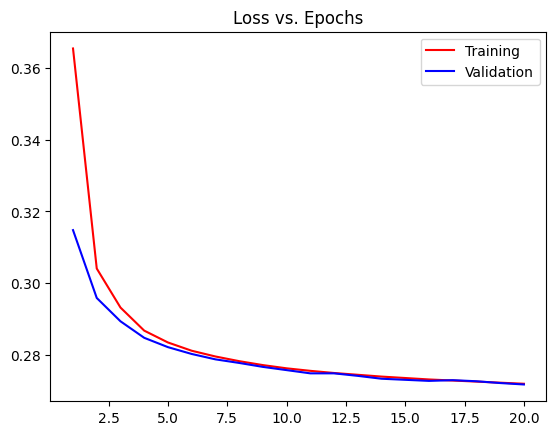

In [4]:
X1_TRAINNING = [0.3654,0.3041,0.29323,0.2868,0.2835,0.2812,0.2796,0.2783,0.2772,0.2763,0.2756,0.2750,0.2745,0.2740,0.2736,0.2732,0.2729,0.2726,0.2723,0.2720]
X2_VALIDATION = [0.3148,0.2959,0.2894,0.2848,0.2822,0.2803,0.2788,0.2778,0.2767,0.2758,0.2749,0.2749,0.2742,0.2734,0.2731,0.2728,0.2730,0.2727,0.2722,0.2718]
import matplotlib.pyplot as plt
plt.plot(range(1, len(X1_TRAINNING) + 1), X1_TRAINNING, color='red', label='Training')
plt.plot(range(1, len(X2_VALIDATION) + 1), X2_VALIDATION, color='blue', label='Validation')
plt.title('Loss vs. Epochs')
plt.legend()
plt.show()
